# **Atelier Préparation de Données Textuelles**

## **Partie 1 – Exploration du corpus**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **1.1 Chargement des données du corpus**

In [2]:
corpus = pd.read_csv("../data/smart_reviews_raw.csv")
corpus.head()

,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,positif,5,fr


### **1.2 Combien d'avis contient le dataset**

In [3]:
print(f"le nombre d'avis du carpus: {corpus.shape[0]} avis")

le nombre d'avis du carpus: 1200 avis


### **1.3 Combien de colonnes possède-t-il ?**

In [4]:
print(f"le nombre de colonnes du carpus: {corpus.shape[1]}")

le nombre de colonnes du carpus: 8


### **1.4 Quel est le type de chaque colonne ?**

In [5]:
corpus.dtypes

id_avis        str
date           str
source         str
produit        str
texte          str
sentiment      str
note         int64
langue         str
dtype: object

### **1.5 Vérification des valeurs manquantes**

In [6]:
corpus.isna().sum()

id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64

On observe 5 valeurs manquantes dans au niveau de la colonnne texte

### **1.6 Identifier quelques types de texte en affichant par exemple :** 

**`texte normal ;`** 

**`texte vide ;`** 

**`texte contenant une URL ;`** 

**`texte contenant une mention ;`** 

**`texte contenant un hashtag ;`** 

**`texte contenant des emojis ;`** 

**`texte avec beaucoup de ponctuation ;`** 

**`texte en majuscules ;`** 

**`texte avec répétition de caractères`**

**`texte normal ;`** 

In [7]:
corpus[['texte']].head(1)

,texte
0,"Très bonne expérience, simple et efficace."


**`texte vide ;`** 

In [8]:
print(corpus[corpus['texte'].isna()]['texte'])

46     NaN
108    NaN
310    NaN
640    NaN
781    NaN
Name: texte, dtype: str


In [9]:
def est_vide(texte):
    return pd.isna(texte) or str(texte).strip() == ""

In [10]:
# est_vide travaille sur UN texte : pour l'appliquer à toute la colonne, on utilise .apply()
masque_vide = corpus['texte'].apply(est_vide)
print(f"Nombre de textes vides : {masque_vide.sum()}")
corpus[masque_vide][['id_avis', 'texte']]

Nombre de textes vides : 6


,id_avis,texte
46,AV0047,NaN
108,AV0109,NaN
310,AV0311,NaN
640,AV0641,NaN
781,AV0782,NaN
951,AV0952,


**`texte contenant une URL ;`**

In [11]:
corpus[corpus['texte'].str.contains(r'https?://|www\.', regex=True, na=False)][['texte']].head(5)

,texte
16,"Produit parfait, rien à signaler. https://exam..."
30,"Très bonne expérience, simple et efficace. htt..."
31,"Je viens de recevoir le produit, à voir dans l..."
34,"Produit parfait, rien à signaler. https://exam..."
35,"Très bon produit, la qualité est au rendez-vou..."


**`texte contenant une mention ;`**

In [12]:
corpus[corpus['texte'].str.contains(r'@\w+', regex=True, na=False)][['texte']].head(5)

,texte
9,@client Livraison rapide et produit conforme à...
32,@client Service client réactif et commande reç...
40,@client La qualité est correcte sans être exce...
44,"@client Je recommande vivement, tout fonctionn..."
45,@client Excellent rapport qualité-prix.


**`texte contenant un hashtag ;`**

In [13]:
corpus[corpus['texte'].str.contains(r'#\w+', regex=True, na=False)][['texte']].head(5)

,texte
1,Très satisfait de mon achat 👍 #avis
12,La batterie tient vraiment bien et l'écran est...
15,Produit correct pour son prix. #avis
38,"Très bonne expérience, simple et efficace. #avis"
69,La batterie tient vraiment bien et l'écran est...


**`texte contenant des emojis ;`**

In [14]:
corpus[corpus['texte'].str.contains(r'[\U0001F300-\U0001FAFF☀-➿]', regex=True, na=False)][['texte']].head(5)

,texte
1,Très satisfait de mon achat 👍 #avis
5,Très satisfait de mon achat 👍 😊
7,Très satisfait de mon achat 👍
10,Très satisfait de mon achat 👍 !!!
19,"Je viens de recevoir le produit, à voir dans l..."


**`texte avec beaucoup de ponctuation ;`** (au moins 2 signes `!`, `?` ou `.` consécutifs)

In [15]:
corpus[corpus['texte'].str.contains(r'[!?.]{2,}', regex=True, na=False)][['texte']].head(5)

,texte
3,"Produit excellent, je suis très satisfait. !!!"
10,Très satisfait de mon achat 👍 !!!
14,Qualité décevante pour ce prix. !!!
25,"Produit reçu endommagé, je suis mécontent. !!!"
37,"Produit excellent, je suis très satisfait. !!!"


**`texte en majuscules ;`**

In [16]:
corpus[corpus['texte'].str.isupper().fillna(False)][['texte']].head(5)

,texte
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...
17,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...
23,"PRODUIT EXCELLENT, JE SUIS TRÈS SATISFAIT."
24,TRÈS SATISFAIT DE MON ACHAT 👍


**`texte avec répétition de caractères`** (un même caractère 3 fois ou plus d'affilée)

In [17]:
# La backreference \1 impose un groupe capturant, ce qui fait râler str.contains ;
# str.extract est fait pour les groupes : une ligne est retenue si le motif a été trouvé
masque_repetition = corpus['texte'].str.extract(r'((.)\2{2,})')[0].notna()
corpus[masque_repetition][['texte']].head(5)

,texte
3,"Produit excellent, je suis très satisfait. !!!"
10,Très satisfait de mon achat 👍 !!!
14,Qualité décevante pour ce prix. !!!
25,"Produit reçu endommagé, je suis mécontent. !!!"
28,"Produit excellent, je suis trèèès satisfait."


### **1.7 Mesure de la longueur des textes en créant :une nouvelle colonne « longueur » pour déterminer : longueur minimale ; longueur maximale ; longueur moyenne ; médiane et quartiles.**

In [18]:
corpus["longueur"] = corpus['texte'].str.strip().str.len()
corpus[['texte', 'longueur']].head()

,texte,longueur
0,"Très bonne expérience, simple et efficace.",47.0
1,Très satisfait de mon achat 👍 #avis,35.0
2,"Produit parfait, rien à signaler.",37.0
3,"Produit excellent, je suis très satisfait. !!!",46.0
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,55.0


In [19]:
print(f"longeur min: {corpus['longueur'].min()}")

longeur min: 0.0


In [20]:
print(f"longeur max: {corpus['longueur'].max()}")

longeur max: 635.0


In [21]:
print(f"longeur mediane: {corpus['longueur'].median()}")

longeur mediane: 48.0


In [22]:
print(f"longeur moyenne: {corpus['longueur'].mean().round(2)}")

longeur moyenne: 49.16


In [23]:
print(f"le 1 er quartile: {corpus['longueur'].quantile(.25)}")

le 1 er quartile: 37.0


In [24]:
print(f"le 3 eme quartile: {corpus['longueur'].quantile(.75)}")

le 3 eme quartile: 56.0


### **1.8 Visualiser la distribution de la longueur des avis**

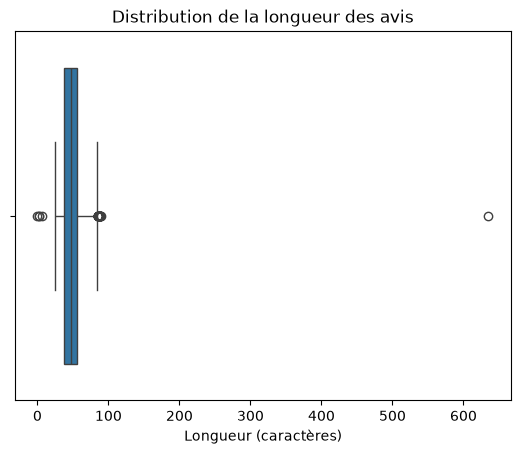

In [25]:
sns.boxplot(data=corpus, x='longueur')
plt.title("Distribution de la longueur des avis")
plt.xlabel("Longueur (caractères)")
plt.show()

#### **a) Existe-t-il des textes anormalement longs ?**

**Oui, mais très peu.** Sur 41 avis au-dessus de la borne du boxplot (84,5 caractères) :

- 40 font 85 à 89 caractères : des avis normaux avec une URL collée, donc du bruit à nettoyer.
- 1 seul est réellement aberrant : 635 caractères (13 fois la médiane), une même phrase répétée 12 fois.

In [26]:
q1, q3 = corpus['longueur'].quantile([.25, .75])
borne_haute = q3 + 1.5 * (q3 - q1)
longs = corpus[corpus['longueur'] > borne_haute]

print(f"Borne haute : {borne_haute}")
print(f"Avis au-dessus de la borne : {len(longs)}")
print(f"Dont avec une URL : {longs['texte'].str.contains('http', na=False).sum()}")
print(f"Longueur max : {corpus['longueur'].max()}")

Borne haute : 84.5
Avis au-dessus de la borne : 41
Dont avec une URL : 40
Longueur max : 635.0


#### **b) Existe-t-il beaucoup de textes très courts ?**

**Non.** Seulement 4 avis font moins de 10 caractères (0,33 % des textes renseignés) : un texte vide, « OK » (2 fois) et « Pas bon ». Les avis sont très homogènes (5ᵉ percentile à 31 caractères).

In [27]:
courts = corpus[corpus['longueur'] < 10]

print(f"Avis < 10 caractères : {len(courts)}")
print(f"Part des textes renseignés : {len(courts) / corpus['longueur'].notna().sum():.2%}")
print(f"5e percentile : {corpus['longueur'].quantile(.05)}")
print(courts['texte'].value_counts(dropna=False))

Avis < 10 caractères : 4
Part des textes renseignés : 0.33%
5e percentile : 31.0
texte
OK         2
Pas bon    1
           1
Name: count, dtype: int64


### **1.9 Détection des textes vides**

In [28]:
corpus[corpus['longueur'] == 0]

,id_avis,date,source,produit,texte,sentiment,note,langue,longueur
951,AV0952,2026-06-11,web,Ordinateur NovaBook,,positif,4,fr,0.0


### **1.10 Détection des doublons sur le texte**

In [29]:
corpus[corpus['texte'].duplicated()]['texte']

11                  Produit  parfait,  rien  à  signaler.
17      SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...
27                        Excellent rapport qualité-prix.
37         Produit excellent, je suis très satisfait. !!!
41           Produit excellent, je suis trèèès satisfait.
                              ...                        
1195          La batterie se décharge beaucoup trop vite.
1196       Très bonne expérience, simple et efficace. !!!
1197                   Produit correct pour son prix. !!!
1198                Excellent rapport qualité-prix. #avis
1199    @client Service client réactif et commande reç...
Name: texte, Length: 881, dtype: str

### **1.11 Les classes sont-elles équilibrées ?**

In [30]:
corpus['sentiment'].value_counts()

sentiment
positif    776
neutre     246
negatif    178
Name: count, dtype: int64

On vois un desequilibre entre les classes

### **1.12 Quelle est la classe majoritaire ?**

In [31]:
corpus['sentiment'].mode()

0    positif
Name: sentiment, dtype: str

On observe que la majorité des sentiments sont positif

### **1.13 Quelles métriques de classification à envisager d’utiliser ?**

In [32]:
# Un modèle qui prédit toujours « positif » aurait quelle accuracy ?
proportions = corpus['sentiment'].value_counts(normalize=True)
print(proportions.round(3))
print(f"Accuracy d'un modèle qui prédit toujours '{proportions.idxmax()}' : {proportions.max():.1%}")

sentiment
positif    0.647
neutre     0.205
negatif    0.148
Name: proportion, dtype: float64
Accuracy d'un modèle qui prédit toujours 'positif' : 64.7%


**À éviter : l'accuracy seule.** Avec 64,7 % d'avis positifs, un modèle qui prédit toujours « positif » obtient 64,7 % d'accuracy sans rien apprendre, et rate toutes les classes minoritaires (neutre 20,5 %, négatif 14,8 %).

**Métriques à privilégier :**
- **Précision, rappel et F1-score par classe** (`classification_report`) : elles montrent comment chaque classe est traitée, y compris les minoritaires.
- **Macro-F1** : moyenne des F1 des 3 classes, chacune pesant autant. C'est la métrique principale ici.
- **Matrice de confusion** : pour voir quelles classes sont confondues (par exemple neutre / positif).
- **Balanced accuracy** : moyenne des rappels par classe, alternative simple à l'accuracy.

En complément, on utilisera un découpage **stratifié** (`stratify=y`) pour garder les mêmes proportions en entraînement et en test.

### **1.14 Détecter les caractères particuliers : emojis ; URLs ; hashtags ; mentions ; chiffres ; caractères spéciaux ; ponctuation répétée ; …**

In [33]:
motifs = {
    'emojis': r'[\U0001F300-\U0001FAFF☀-➿]',
    'URLs': r'https?://|www\.',
    'hashtags': r'#\w+',
    'mentions': r'@\w+',
    'chiffres': r'\d',
    'caractères spéciaux': r"[^\w\s.,!?'’:;@#/-]",
    'ponctuation répétée': r'[!?.]{2,}',
    'espaces multiples': r'\s{2,}',
}

nb_avis = pd.Series({nom: corpus['texte'].str.contains(motif, regex=True, na=False).sum()
                     for nom, motif in motifs.items()})
pd.DataFrame({'nb_avis': nb_avis, 'part (%)': (nb_avis / len(corpus) * 100).round(1)})

,nb_avis,part (%)
emojis,192,16.0
URLs,143,11.9
hashtags,127,10.6
mentions,128,10.7
chiffres,142,11.8
caractères spéciaux,192,16.0
ponctuation répétée,141,11.8
espaces multiples,125,10.4


Environ 10 à 16 % des avis contiennent chaque type d'élément : emojis (192), URLs (143), mentions (128), hashtags (127), ponctuation répétée (141) et espaces multiples (125). Les chiffres (142) viennent uniquement des URLs (`.../commande/17`) et les caractères spéciaux sont les emojis. Ces éléments seront à nettoyer ou à traiter avant la modélisation.

### **1.15 Visualisation et commentaire du nombre d'avis par source**

In [34]:
corpus.head()

,id_avis,date,source,produit,texte,sentiment,note,langue,longueur
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr,47.0
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr,35.0
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr,37.0
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr,46.0
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,positif,5,fr,55.0


source
réseaux_sociaux    251
email              247
sav                239
web                232
mobile             230
WEB                  1
Name: count, dtype: int64


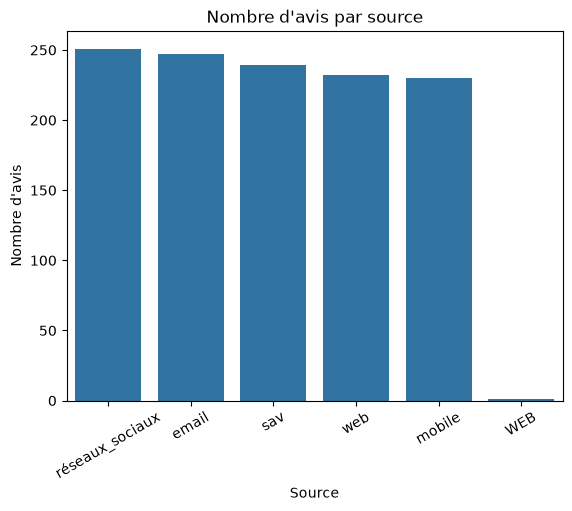

In [35]:
avis_par_source = corpus['source'].value_counts()
print(avis_par_source)

sns.barplot(x=avis_par_source.index, y=avis_par_source.values)
plt.title("Nombre d'avis par source")
plt.xlabel("Source")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=30)
plt.show()

Les avis sont **répartis de façon équilibrée** entre les 5 sources, chacune représentant environ 19 à 21 % du corpus (réseaux_sociaux 251, email 247, sav 239, web 232, mobile 230). Anomalie : une valeur `WEB` en majuscules (1 avis), à normaliser en `web` lors du nettoyage.

### **1.16 Visualisation et commentaire du nombre d'avis par produit**

In [36]:
corpus.head(3)

,id_avis,date,source,produit,texte,sentiment,note,langue,longueur
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr,47.0
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr,35.0
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr,37.0


produit
Écouteurs AirSound     218
Ordinateur NovaBook    217
SmartPhone X           201
SmartWatch Pro         193
Tablette TabPlus       187
SmartPhone Y           184
Name: count, dtype: int64


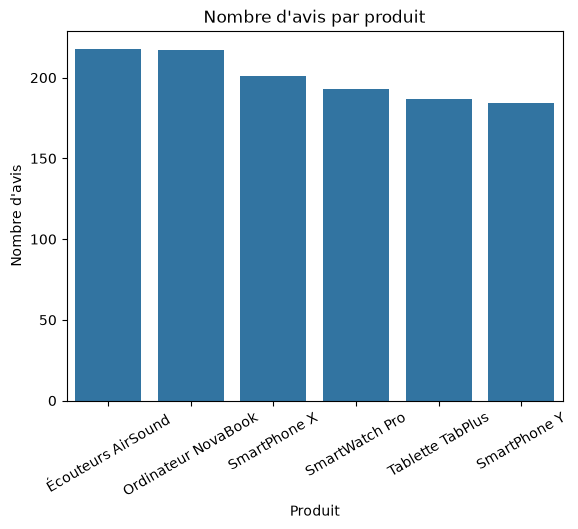

In [37]:
avis_par_produit = corpus['produit'].value_counts()
print(avis_par_produit)

sns.barplot(x=avis_par_produit.index, y=avis_par_produit.values)
plt.title("Nombre d'avis par produit")
plt.xlabel("Produit")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=30)
plt.show()

Les avis sont **répartis assez équitablement** entre les 6 produits (15 à 18 % chacun). Écouteurs AirSound (218) et Ordinateur NovaBook (217) sont les plus commentés, SmartPhone Y (184) le moins, soit un écart de moins de 20 % entre le plus et le moins représenté. Aucun produit ne domine le corpus.

## **Partie 2 – Nettoyage**

### **2.1 Suppression des lignes contenant des valeurs manquantes de texte**

In [38]:
corpus.shape

(1200, 9)

In [39]:
corpus = corpus.dropna(subset=['texte']).reset_index(drop=True)
corpus.shape

(1195, 9)

### **2.2 Supprimer les doublons**

In [40]:
corpus.drop_duplicates(subset=['texte'], inplace=True)
corpus.shape

(318, 9)

### **2.3 Suppression des URLs**

In [41]:
motif_url = r'https?://\S+|www\.\S+'

print(f"Avis avec URL avant : {corpus['texte'].str.contains(motif_url).sum()}")
corpus['texte'] = corpus['texte'].str.replace(motif_url, '', regex=True).str.strip()
print(f"Avis avec URL après : {corpus['texte'].str.contains(motif_url).sum()}")

Avis avec URL avant : 143
Avis avec URL après : 0


### **2.4 Traitement des mentions et hashtags avec la stratégie la plus pertinente pour une classification de sentiment**

**Stratégie retenue :** supprimer les mentions (`@client`, `@support` : simples destinataires, sans sentiment) et garder le mot des hashtags en retirant le `#`, car il peut porter du sentiment (`#déception`).

In [42]:
print(f"Avis avec mention avant : {corpus['texte'].str.contains(r'@\w+').sum()}")
print(f"Avis avec hashtag avant : {corpus['texte'].str.contains(r'#\w+').sum()}")

# Mentions : supprimées (@client n'indique aucun sentiment)
corpus['texte'] = corpus['texte'].str.replace(r'@\w+', '', regex=True)
# Hashtags : on garde le mot (ex. #déception) en retirant seulement le '#'
corpus['texte'] = corpus['texte'].str.replace('#', '', regex=False).str.strip()

print(f"Avis avec mention après : {corpus['texte'].str.contains(r'@\w+').sum()}")
print(f"Avis avec hashtag après : {corpus['texte'].str.contains('#').sum()}")

Avis avec mention avant : 24
Avis avec hashtag avant : 25
Avis avec mention après : 0
Avis avec hashtag après : 0


### **2.5 Nettoyage des espaces**

In [43]:
print(f"Avis avec espaces multiples avant : {corpus['texte'].str.contains(r'\s{2,}').sum()}")

# Remplace toute suite d'espaces (ou tabulations, retours à la ligne) par un seul espace
corpus['texte'] = corpus['texte'].str.replace(r'\s+', ' ', regex=True).str.strip()

print(f"Avis avec espaces multiples après : {corpus['texte'].str.contains(r'\s{2,}').sum()}")

Avis avec espaces multiples avant : 26
Avis avec espaces multiples après : 0


### **2.6 Traiter la ponctuation avec la stratégie la plus pertinente pour une classification de sentiment**

**Stratégie retenue :** réduire la ponctuation répétée à un seul signe (`!!!` → `!`) et conserver `!` et `?`, qui expriment l'émotion (enthousiasme, colère), utile pour le sentiment. Supprimer toute la ponctuation ferait perdre cette information.

In [44]:
motif_ponct = r'([!?.,;:])\1+'

print(f"Avis avec ponctuation répétée avant : {(corpus['texte'].str.count(motif_ponct) > 0).sum()}")
# '!!!' devient '!' : on garde un seul signe pour conserver l'intensité émotionnelle
corpus['texte'] = corpus['texte'].str.replace(motif_ponct, r'\1', regex=True)
print(f"Avis avec ponctuation répétée après : {(corpus['texte'].str.count(motif_ponct) > 0).sum()}")

Avis avec ponctuation répétée avant : 26
Avis avec ponctuation répétée après : 0


### **2.7 Créer une fonction de nettoyage pour automatiser les actions ci-dessus**

In [45]:
import re

def nettoyer_texte(texte):
    texte = re.sub(r'https?://\S+|www\.\S+', '', texte)   # URLs supprimées
    texte = re.sub(r'@\w+', '', texte)                    # mentions supprimées
    texte = texte.replace('#', '')                        # hashtags : on garde le mot
    texte = re.sub(r'([!?.,;:])\1+', r'\1', texte)        # ponctuation répétée réduite
    return re.sub(r'\s+', ' ', texte).strip()             # espaces normalisés

# Test sur un exemple
nettoyer_texte("@client Très satisfait !!!  https://example.com/commande/17 #avis")

'Très satisfait ! avis'

In [46]:
corpus['texte'].apply(nettoyer_texte).head()

0           Très bonne expérience, simple et efficace.
1                   Très satisfait de mon achat 👍 avis
2                    Produit parfait, rien à signaler.
3         Produit excellent, je suis très satisfait. !
4    LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...
Name: texte, dtype: str

### **2.8 Stocker sur une colonne texte_clean, les textes ayant subi les traitements ci-dessus**

In [47]:
corpus['texte_clean'] = corpus['texte'].apply(nettoyer_texte)
corpus[['texte', 'texte_clean']].head()

,texte,texte_clean
0,"Très bonne expérience, simple et efficace.","Très bonne expérience, simple et efficace."
1,Très satisfait de mon achat 👍 avis,Très satisfait de mon achat 👍 avis
2,"Produit parfait, rien à signaler.","Produit parfait, rien à signaler."
3,"Produit excellent, je suis très satisfait. !","Produit excellent, je suis très satisfait. !"
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...


### **2.9 Vérifier le contenu des colonnes texte et texte_clean sur les 10 premières observations**

In [48]:
corpus[['texte', 'texte_clean']].head(10)

,texte,texte_clean
0,"Très bonne expérience, simple et efficace.","Très bonne expérience, simple et efficace."
1,Très satisfait de mon achat 👍 avis,Très satisfait de mon achat 👍 avis
2,"Produit parfait, rien à signaler.","Produit parfait, rien à signaler."
3,"Produit excellent, je suis très satisfait. !","Produit excellent, je suis très satisfait. !"
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...
5,Très satisfait de mon achat 👍 😊,Très satisfait de mon achat 👍 😊
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...
7,Très satisfait de mon achat 👍,Très satisfait de mon achat 👍
8,Le produit correspond globalement à la descrip...,Le produit correspond globalement à la descrip...
9,Livraison rapide et produit conforme à mes att...,Livraison rapide et produit conforme à mes att...


## **Partie 3 – Tokenisation**

### **3.1 Pourquoi split() n'est-il pas suffisant pour une vraie application NLP ?**

In [49]:
exemple = "L'écran est superbe, je l'adore ! Très satisfait 👍 (vraiment) c'est pas mal."
exemple.split()

["L'écran",
 'est',
 'superbe,',
 'je',
 "l'adore",
 '!',
 'Très',
 'satisfait',
 '👍',
 '(vraiment)',
 "c'est",
 'pas',
 'mal.']

`split()` découpe seulement sur les espaces, ce qui pose plusieurs problèmes :

- **Ponctuation collée aux mots** : `'superbe,'`, `'mal.'` et `'(vraiment)'` deviennent des tokens différents de `'superbe'`, `'mal'` et `'vraiment'`, ce qui gonfle le vocabulaire.
- **Contractions non séparées** : `"L'écran"` et `"c'est"` restent d'un seul bloc, alors que le français demande de séparer `l'` / `écran` et `c'` / `est`.
- **Emojis et symboles** : ils ne sont isolés que s'ils sont entourés d'espaces (`👍 😊` ok, mais `bien👍` resterait collé).
- **Aucune règle linguistique** : il ne gère pas les mots composés (`qualité-prix`), les nombres ni les abréviations.

Une vraie tokenisation (`nltk`, `spacy` ou une regex) applique des règles adaptées à la langue.

### **3.2 Utilisation de la bibliothèque NLTK pour déterminer :**



#### **a. le nombre de tokens de chaque texte,**

In [ ]:
import os
import certifi
os.environ['SSL_CERT_FILE'] = certifi.where()   

import nltk
nltk.download('punkt_tab')

In [62]:
def nbr_tokens(texte):
     tokens = nltk.word_tokenize(texte, language='french')
     return len(tokens)

In [63]:
corpus["nbr_token"] = corpus['texte'].apply(nbr_tokens)

In [66]:
corpus[['texte', 'nbr_token']].head()

,texte,nbr_token
0,"Très bonne expérience, simple et efficace.",8
1,Très satisfait de mon achat 👍 avis,7
2,"Produit parfait, rien à signaler.",7
3,"Produit excellent, je suis très satisfait. !",9
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,10


#### **b. le nombre moyen de tokens ;,**

In [68]:
print(f"le nombre moyen de token: {corpus['nbr_token'].mean().round(2)}")

le nombre moyen de token: 8.29


#### **c. texte avec le plus grand nombre de tokens**

In [72]:
idx_max = corpus['nbr_token'].idxmax()
print(f"Nombre de tokens : {corpus.loc[idx_max, 'nbr_token']}")
print(corpus.loc[idx_max, 'texte'])

Nombre de tokens : 144
Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue.


#### **d. texte avec le plus petit nombre de tokens**

In [73]:
idx_min = corpus['nbr_token'].idxmin()
print(f"Nombre de tokens : {corpus.loc[idx_min, 'nbr_token']}")
print(corpus.loc[idx_min, 'texte'])

Nombre de tokens : 0



## **Partie 4 – Normalisation**

### **4.1 Uniformiser la casse en minuscules. Pourquoi ce traitement ?**

Un ordinateur considère `Excellent`, `EXCELLENT` et `excellent` comme trois mots différents, alors qu'ils ont le même sens. Passer en minuscules permet de :

- **regrouper les variantes d'un même mot**, ce qui réduit la taille du vocabulaire ;
- **éviter de diluer l'information** : un mot n'est pas compté à part selon sa place dans la phrase (début de phrase) ou parce qu'il est écrit en majuscules (`TRÈS SATISFAIT`) ;
- **simplifier et fiabiliser le modèle** : moins de variables, donc moins de bruit et de risque de surapprentissage.

Limite : on perd l'information « cri » des textes tout en majuscules, qui peut exprimer une émotion forte. Pour un sentiment, le gain de regroupement l'emporte le plus souvent.

In [80]:
def taille_vocabulaire(textes):
    return textes.str.findall(r'\w+').explode().nunique()

print(f"Vocabulaire avant minuscules : {taille_vocabulaire(corpus['texte_clean'])} mots")
print(f"Vocabulaire après minuscules : {taille_vocabulaire(corpus['texte_clean'].str.lower())} mots")

Vocabulaire avant minuscules : 207 mots
Vocabulaire après minuscules : 102 mots


In [75]:
corpus.head(3)

,id_avis,date,source,produit,texte,sentiment,note,langue,longueur,texte_clean,nbr_token
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr,47.0,"Très bonne expérience, simple et efficace.",8
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 avis,positif,4,fr,35.0,Très satisfait de mon achat 👍 avis,7
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr,37.0,"Produit parfait, rien à signaler.",7


In [79]:
corpus['texte'] = corpus['texte'].str.lower()
corpus['texte'].head()

0           très bonne expérience, simple et efficace.
1                   très satisfait de mon achat 👍 avis
2                    produit parfait, rien à signaler.
3         produit excellent, je suis très satisfait. !
4    la batterie tient vraiment bien et l'écran est...
Name: texte, dtype: str

### **4.2 Faut-il systématiquement supprimer les accents dans un corpus français ?**

**Non, pas systématiquement.** En français, l'accent change parfois le sens du mot :

- `a` (verbe avoir) / `à` (préposition), `ou` / `où`, `sur` / `sûr` : sans accent, ces mots se confondent.
- Supprimer les accents dégrade la lisibilité et peut brouiller les mots porteurs de sentiment (`déçu` devient `decu`).

**Quand le faire :** seulement si le corpus contient beaucoup de fautes ou d'accents oubliés (SMS, réseaux sociaux), pour regrouper `très` et `tres`. Ici, les avis sont correctement accentués : on garde les accents.

### **4.3 Quels stop words supprimer ?**

**À supprimer :** les mots grammaticaux très fréquents qui n'expriment aucun sentiment : articles (`le`, `la`, `les`, `un`), prépositions (`de`, `à`, `pour`), pronoms (`je`, `il`), conjonctions simples (`et`) et formes courantes de `être` / `avoir` (`est`, `a`, `suis`).



### **4.4 Quels stop words conserver?**

**À conserver, car ils portent le sentiment :**
- **les négations** : `pas`, `ne`, `jamais`, `sans`, `plus`, `rien` (« pas bon » n'a pas le même sens que « bon ») ;
- **les mots d'intensité** : `très`, `trop`, `peu`, `beaucoup` ;
- **le mot de contraste** `mais` (« correct, mais lent »).

 

### **4.5 Appliquer la technique (stemming ou lemmatisation) la plus adaptée ?**

**Choix : la lemmatisation.** Elle ramène chaque mot à sa forme de dictionnaire (`recommande` → `recommander`, `tient` → `tenir`, `décevante` → `décevant`), alors que le stemming coupe simplement les fins de mots. Sur ce corpus, le stemming (Snowball) donne des racines qui ne sont pas de vrais mots (`satisf`, `rapid`), incohérentes entre elles (`satisfait` → `satisf` mais `satisfaits` → `satisfait`) et il supprime les accents (`très` → `tres`).

NLTK ne propose pas de lemmatiseur français (celui de WordNet ne fonctionne qu'en anglais) : on utilise la bibliothèque `simplemma`.

In [82]:
import simplemma

def lemmatiser(texte):
    tokens = nltk.word_tokenize(texte, language='french')
    return ' '.join(simplemma.lemmatize(mot, lang='fr') for mot in tokens)

corpus['texte_lemma'] = corpus['texte_clean'].str.lower().apply(lemmatiser)
corpus[['texte_clean', 'texte_lemma']].head()

,texte_clean,texte_lemma
0,"Très bonne expérience, simple et efficace.","très bon expérience , simple et efficace ."
1,Très satisfait de mon achat 👍 avis,très satisfait de son achat 👍 avis
2,"Produit parfait, rien à signaler.","produit parfait , rien à signaler ."
3,"Produit excellent, je suis très satisfait. !","produit excellent , moi être très satisfait . !"
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,le batterie tenir vraiment bien et écran être ...
